In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [10]:
data = pd.read_csv('all_stocks_5yr.csv', delimiter=',', on_bad_lines='skip')
print(data.shape)


(619040, 7)


In [11]:
print(data.sample(7))

              date    open    high       low   close    volume  Name
123457  2014-06-20   51.09   51.27   50.7000   50.96   1095819   CMA
414567  2016-01-28  176.40  181.19  175.0000  180.15   2078998   NOC
434967  2017-11-14   56.68   56.97   56.3100   56.90   1496755     O
522704  2015-08-12   50.58   51.68   49.7700   51.62   4264220   STX
322655  2017-06-20   18.76   18.76   18.5700   18.57   5331678   KEY
422925  2014-04-08   18.21   18.91   18.1803   18.86  11767342  NVDA
243912  2017-09-14   24.10   24.27   23.9400   24.26  42084528    GE


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


In [13]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


In [14]:
data.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [15]:
data['Name'] = data['Name'].str.strip()

In [16]:
print('GOOGL' in data['Name'].values)
print('GOOG' in data['Name'].values)

True
True


In [17]:
companies = ['AAPL', 'AMD', 'FB', 'GOOG', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

In [18]:
data[data['Name'].str.contains('AAPL', case=False, na=False)]

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
2513,2018-02-01,167.1650,168.6200,166.7600,167.7800,47230787,AAPL
2514,2018-02-02,166.0000,166.8000,160.1000,160.5000,86593825,AAPL
2515,2018-02-05,159.1000,163.8800,156.0000,156.4900,72738522,AAPL
2516,2018-02-06,154.8300,163.7200,154.0000,163.0300,68243838,AAPL


In [19]:
data['Name'] = data['Name'].astype(str).str.strip()

print(data['Name'].unique())

for company in companies:
    c = data[data['Name'] == company]
    print(company, c.shape)

<StringArray>
[ 'AAL', 'AAPL',  'AAP', 'ABBV',  'ABC',  'ABT',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
 'XLNX',   'XL',  'XOM', 'XRAY',  'XRX',  'XYL',  'YUM',  'ZBH', 'ZION',
  'ZTS']
Length: 505, dtype: str
AAPL (1259, 7)
AMD (1259, 7)
FB (1259, 7)
GOOG (975, 7)
AMZN (1259, 7)
NVDA (1259, 7)
EBAY (1259, 7)
CSCO (1259, 7)
IBM (1259, 7)


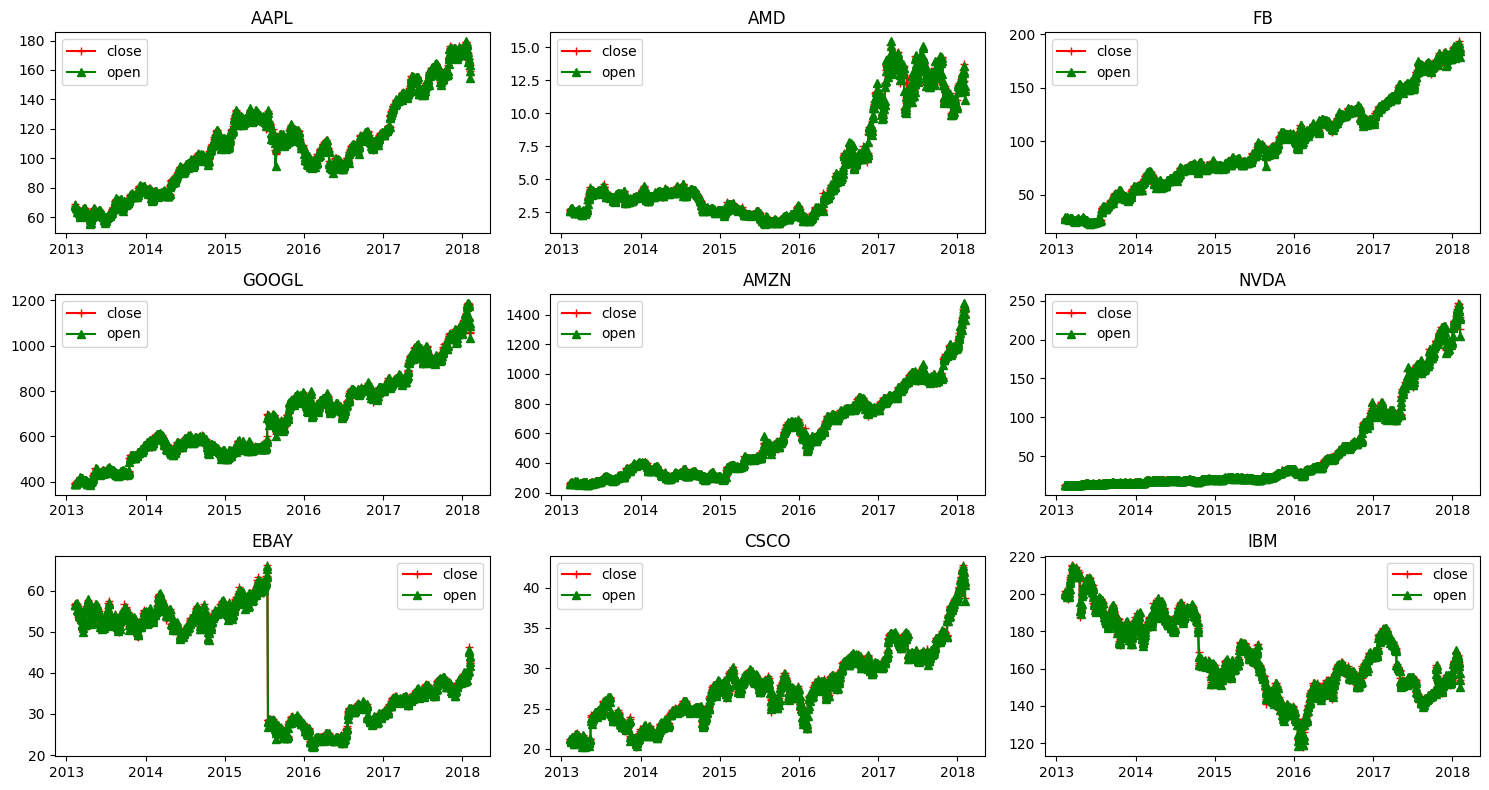

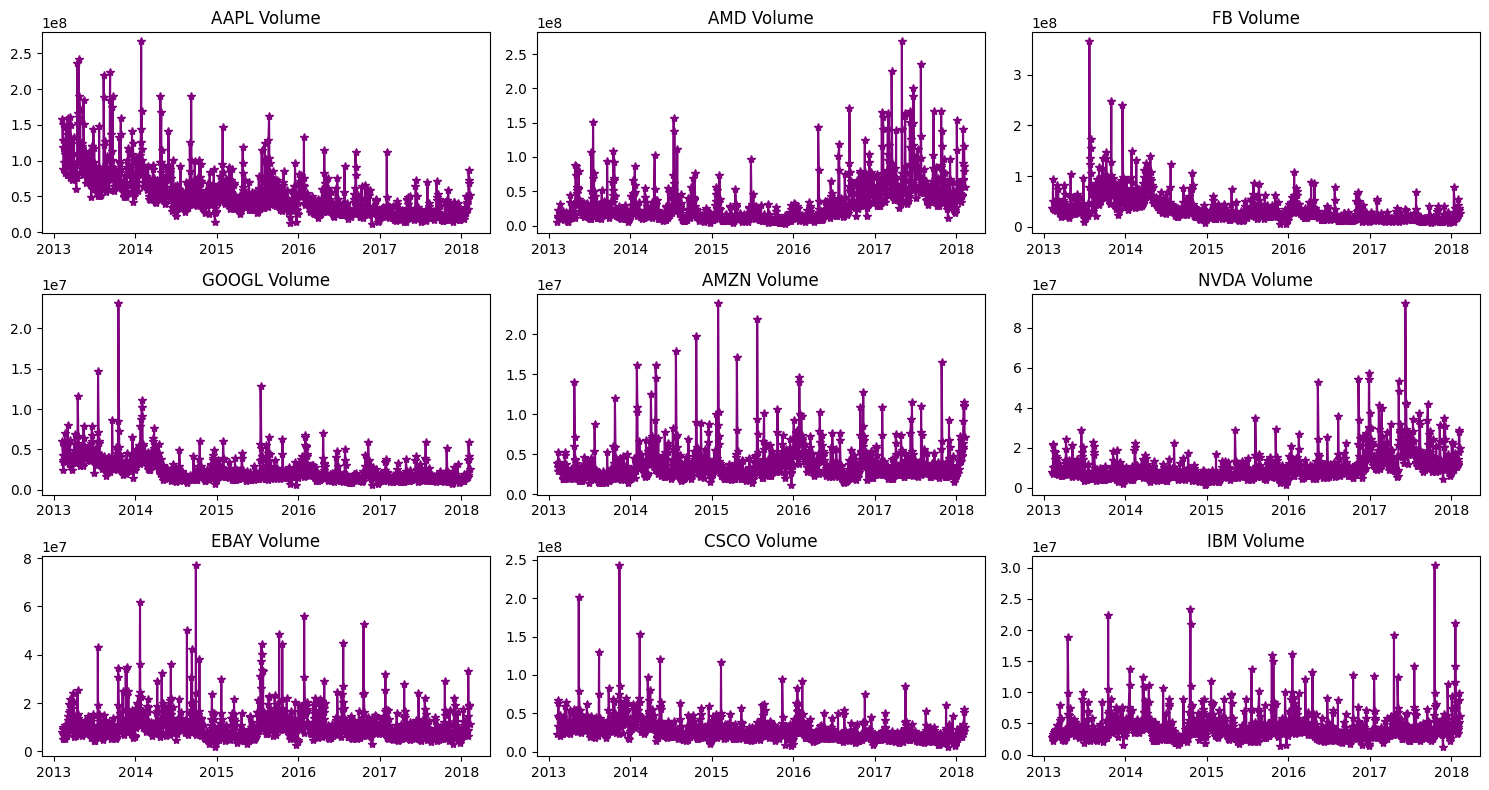

In [20]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c="r", label="close", marker="+")
    plt.plot(c['date'], c['open'], c="g", label="open", marker="^")
    plt.title(company)
    plt.legend()
    plt.tight_layout()

plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='purple', marker='*')
    plt.title(f"{company} Volume")
    plt.tight_layout()

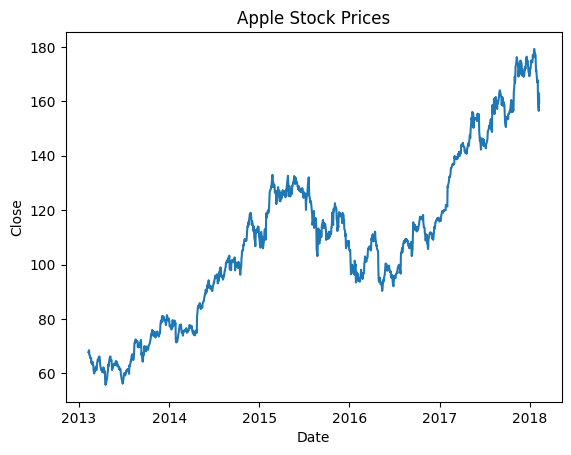

In [21]:
apple = data[data['Name'] == 'AAPL']
prediction_range = apple.loc[(apple['date'] > datetime(2013,1,1))
 & (apple['date']<datetime(2018,1,1))]
plt.plot(apple['date'],apple['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Apple Stock Prices")
plt.show()

In [22]:
close_data = apple.filter(['close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))
print(training)

1197


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training), :]
# prepare feature and labels
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train



array([[[0.0977103 ],
        [0.103438  ],
        [0.08951884],
        ...,
        [0.06362512],
        [0.06878507],
        [0.08119942]],

       [[0.103438  ],
        [0.08951884],
        [0.08848863],
        ...,
        [0.06878507],
        [0.08119942],
        [0.07882556]],

       [[0.08951884],
        [0.08848863],
        [0.08800268],
        ...,
        [0.08119942],
        [0.07882556],
        [0.08482135]],

       ...,

       [[0.8061069 ],
        [0.82360102],
        [0.84279595],
        ...,
        [0.91722692],
        [0.8998138 ],
        [0.90969474]],

       [[0.82360102],
        [0.84279595],
        [0.85696942],
        ...,
        [0.8998138 ],
        [0.90969474],
        [0.9452499 ]],

       [[0.84279595],
        [0.85696942],
        [0.85170499],
        ...,
        [0.90969474],
        [0.9452499 ],
        [0.95942337]]], shape=(1137, 60, 1))

In [44]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(units=64,
                            return_sequences=True,
                            input_shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary

<bound method Model.summary of <Sequential name=sequential_1, built=True>>

In [46]:
model.compile(optimizer='adam',
              loss='mean_squared_error')
history = model.fit(x_train,
                    y_train,
                    epochs=10)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0069
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0059
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0053
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0047
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0049
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0046
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0042
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0044
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0037
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0037


In [47]:
test_data = scaled_data[training - 60:, :]
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

mse = np.mean(((predictions - y_test) ** 2))
rmse = np.sqrt(mse)

print("MSE", mse)
print("RMSE", np.sqrt(mse))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step
MSE 62.122393284082285
RMSE 7.881776023465922


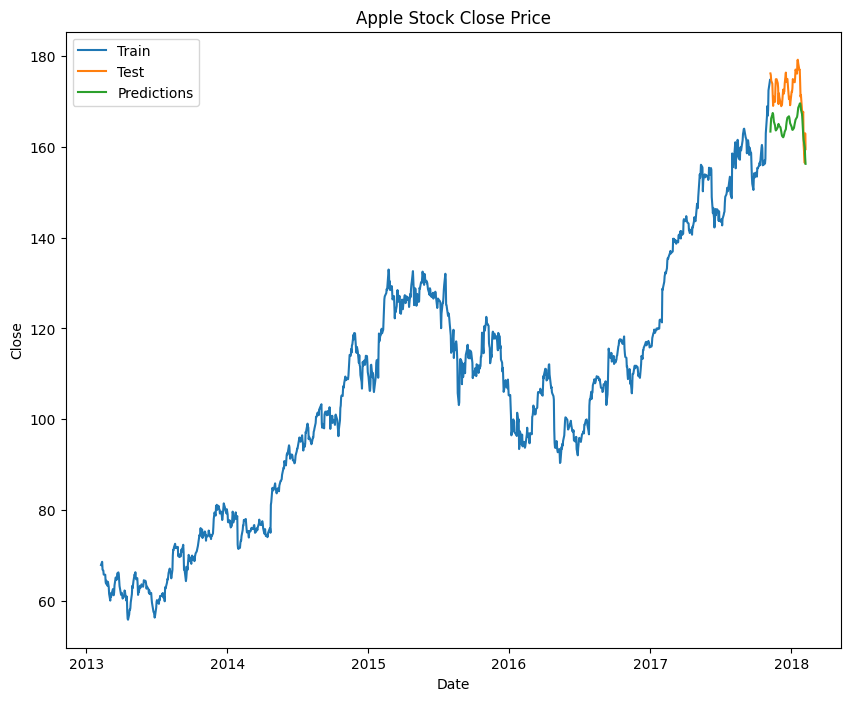

In [48]:
train = apple[:training]
test = apple[training:]
test['Predictions'] = predictions

plt.figure(figsize=(10, 8))
plt.plot(train['date'], train['close'])
plt.plot(test['date'], test[['close', 'Predictions']])
plt.title('Apple Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])